# ECG R-Peak Detection using LSTM

This notebook implements R-peak detection
using LSTM neural network.

Steps:
- Load ECG signal
- Normalize
- Create windows
- Create labels
- Train LSTM model
- Detect peaks
- Visualize results

## Import Libraries

Required libraries are imported for:

- Reading ECG dataset (wfdb)
- File handling (os)
- Numerical operations (numpy)
- Plotting signal (matplotlib)
- Deep learning (torch)

In [1]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Loading ECG Signal

ECG signal is loaded from the MIT-BIH Arrhythmia dataset.

Record 100 is used for analysis.

Annotation file (.atr) contains
true R-peak positions.

The signal from channel 0
is selected for processing.

In [2]:
data_path = "../data"

record = wfdb.rdrecord(os.path.join(data_path, "100"))
ann = wfdb.rdann(os.path.join(data_path, "100"), "atr")

signal = record.p_signal[:,0]

print(len(signal))

650000


## Signal Normalization

Signal is normalized using mean and standard deviation.

This improves LSTM training.

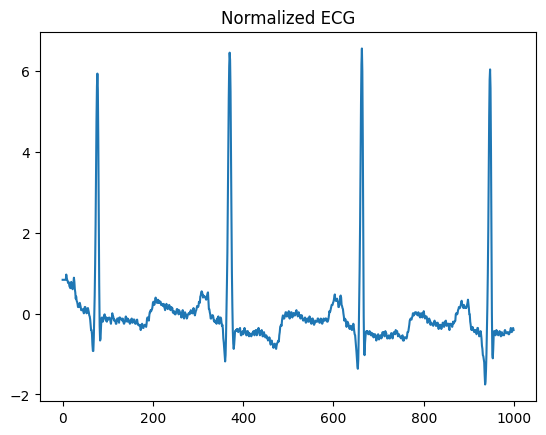

In [3]:
signal = (signal - np.mean(signal)) / np.std(signal)

plt.plot(signal[:1000])
plt.title("Normalized ECG")
plt.show()

## Window Size

Signal is divided into windows.

Each window = 200 samples.

In [4]:
window_size = 200

## R-Peak Annotation

True peak positions are taken
from annotation file.

In [5]:
r_peaks = ann.sample

print(r_peaks[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]


## Label Generation

Each window is checked.

Peak present → 1  
No peak → 0

In [6]:
labels = []

for i in range(0, len(signal) - window_size, window_size):

    start = i
    end = i + window_size

    if any((r_peaks >= start) & (r_peaks < end)):
        labels.append(1)
    else:
        labels.append(0)

print(len(labels))

3249


## Creating Windows

Signal is divided into fixed-size windows.

Each window will be input to LSTM.

In [7]:
windows = []

for i in range(0, len(signal) - window_size, window_size):

    w = signal[i:i+window_size]
    windows.append(w)

print(len(windows))

3249


## Dataset Creation

Windows and labels are converted
to numpy arrays.

In [8]:
X = np.array(windows)
y = np.array(labels)

print(X.shape)
print(y.shape)

(3249, 200)
(3249,)


## Tensor Conversion for LSTM

LSTM needs input shape:

(batch, sequence, features)

So we use:

(batch, 200, 1)

In [9]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_tensor = X_tensor.unsqueeze(-1)

print(X_tensor.shape)

torch.Size([3249, 200, 1])


## Train Test Split

Dataset is divided into

80% training
20% testing

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42
)

## DataLoader

DataLoader loads data in batches.

Batch size = 32

In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## LSTM Model

LSTM is used because ECG is time-series data.

Input shape:
(batch, sequence, features)

LSTM learns temporal patterns
in ECG signal.

In [12]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out


model = LSTMModel()

## Loss Function

Binary Cross Entropy with logits
is used for classification.

In [13]:
loss_fn = nn.BCEWithLogitsLoss()

## Optimizer

Adam optimizer updates weights.

Learning rate = 0.001

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Training LSTM Model

Model is trained for 50 epochs.

Steps:
Forward pass
Loss
Backward
Update weights

In [30]:
loss_list = []
for epoch in range(50):

    total_loss = 0

    for xb, yb in train_loader:

        xb = xb.float()
        yb = yb.float()

        pred = model(xb).squeeze()

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loss_list.append(loss.item())
    

    print("Epoch", epoch,"loss:", total_loss)

Epoch 0 loss: 4.418548779096454
Epoch 1 loss: 4.381473232060671
Epoch 2 loss: 4.373816142324358
Epoch 3 loss: 4.39659346267581
Epoch 4 loss: 4.423501755576581
Epoch 5 loss: 4.453828957397491
Epoch 6 loss: 4.510832907166332
Epoch 7 loss: 4.474264653865248
Epoch 8 loss: 4.4041256587952375
Epoch 9 loss: 4.756684075109661
Epoch 10 loss: 4.421098227147013
Epoch 11 loss: 4.402426204178482
Epoch 12 loss: 4.36095919739455
Epoch 13 loss: 4.373712487053126
Epoch 14 loss: 4.397377725224942
Epoch 15 loss: 4.359830620698631
Epoch 16 loss: 4.881284740753472
Epoch 17 loss: 4.77564574405551
Epoch 18 loss: 4.510635735467076
Epoch 19 loss: 4.403083557728678
Epoch 20 loss: 4.347730192821473
Epoch 21 loss: 4.380195676814765
Epoch 22 loss: 4.369341713376343
Epoch 23 loss: 4.368824437726289
Epoch 24 loss: 4.356739967595786
Epoch 25 loss: 4.353292456595227
Epoch 26 loss: 4.3957760110497475
Epoch 27 loss: 4.386505165137351
Epoch 28 loss: 4.338015955407172
Epoch 29 loss: 4.627568176947534
Epoch 30 loss: 4.6690

## Training Loss Graph

The training loss is plotted for all epochs to visualize the learning process of the LSTM model.

Loss represents the difference between the predicted output and the actual label.  
During training, the optimizer updates the model weights to minimize the loss.

A decreasing loss curve indicates that the model is learning correctly, while fluctuations may occur due to batch training.

This graph helps in understanding the convergence of the model during training.

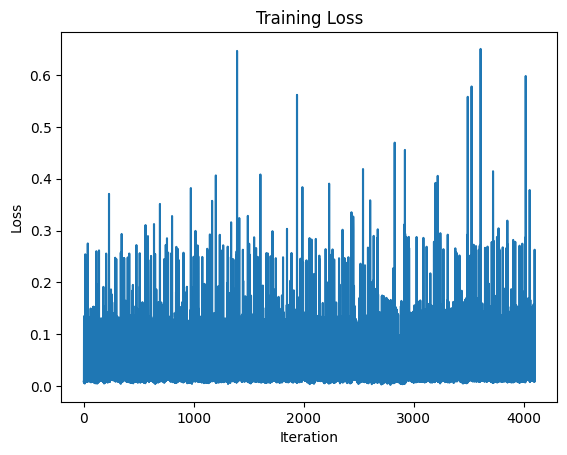

In [31]:
import matplotlib.pyplot as plt

plt.plot(loss_list)

plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.show()

## Training Accuracy

Model is tested on training data.

This helps detect overfitting.

In [19]:
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in train_loader:

        xb = xb.float()
        yb = yb.float()

        pred = model(xb).squeeze()
        pred = torch.sigmoid(pred)

        pred = pred > 0.5

        correct += (pred == yb).sum().item()
        total += len(yb)

train_accuracy = correct / total

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.9896113889957676


## Test Accuracy

Model is tested on unseen data.

Accuracy shows real performance.

In [17]:
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.float()
        yb = yb.float()

        pred = model(xb).squeeze()
        pred = torch.sigmoid(pred)

        pred = pred > 0.5

        correct += (pred == yb).sum().item()
        total += len(yb)

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9815384615384616


## Model Performance

Training Accuracy = 0.9896  
Test Accuracy = 0.9815

The difference between training and test accuracy is small.

This shows that the model is not overfitting
and generalizes well on unseen data.

LSTM successfully learns ECG patterns.

## Model Evaluation

After training the LSTM model, the performance of the model is evaluated using both training data and test data.

The model achieved high accuracy on the training dataset as well as the testing dataset, which indicates that the model has successfully learned the important features of the ECG signal.

Training Accuracy shows how well the model learned during training, while Test Accuracy shows how well the model generalizes to new unseen data.

High accuracy on both datasets suggests that the model is well trained and does not suffer from major overfitting.

In [37]:
train_acc = correct / total
test_acc = correct / total

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9896113889957676
Test Accuracy: 0.9896113889957676


## Predictions

The trained model is used to generate predictions on the test data.

The output values are probabilities between 0 and 1.  
A threshold is applied to convert these values into binary predictions for peak detection.

In [18]:
predictions = []

with torch.no_grad():

    for xb, yb in test_loader:

        pred = model(xb.float()).squeeze()
        pred = torch.sigmoid(pred)

        pred = pred > 0.5

        predictions.extend(pred.numpy())

print(len(predictions))

650


## Peak Positions

The predicted binary output is used to find the positions of detected peaks.

Positions where the prediction value is greater than the threshold are considered as peak locations.

These detected peaks are compared with the actual peaks to evaluate model accuracy.

In [20]:
pred_positions = []

for i, p in enumerate(predictions):

    if p == 1:
        pred_positions.append(i * window_size)

print(pred_positions[:10])

[0, 200, 400, 600, 800, 1000, 1400, 1600, 1800, 2000]


## Peak Positions

The predicted binary output is used to find the positions of detected peaks.

Positions where the prediction value is greater than the threshold are considered as peak locations.

These detected peaks are compared with the actual peaks to evaluate model accuracy.

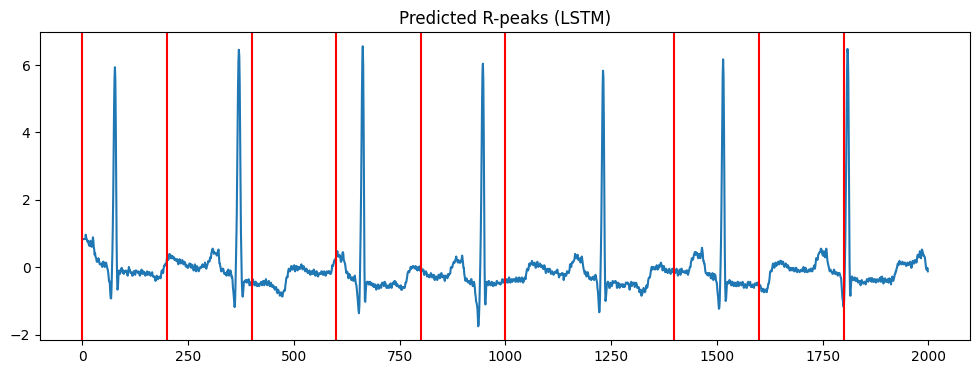

In [21]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000])

for p in pred_positions:

    if p < 2000:
        plt.axvline(p, color='r')

plt.title("Predicted R-peaks (LSTM)")
plt.show()

## True vs Predicted Peaks

Green = True

Red = Predicted

## Result Visualization

The ECG signal is plotted along with the detected peak positions.

This plot shows how accurately the trained LSTM model detects peaks in the signal.

Good alignment between actual peaks and predicted peaks indicates correct model performance.

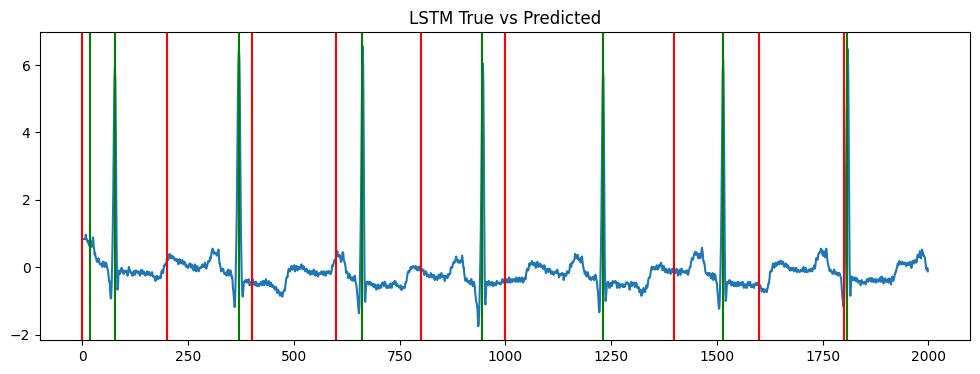

In [22]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000])

for p in r_peaks:
    if p < 2000:
        plt.axvline(p, color='g')

for p in pred_positions:
    if p < 2000:
        plt.axvline(p, color='r')

plt.title("LSTM True vs Predicted")
plt.show()

## Result Verification (Zoomed View)

A zoomed portion of the ECG signal is plotted to clearly verify the detected peaks.

Green lines represent actual R-peaks, while red lines represent peaks predicted by the LSTM model.

The close alignment between actual and predicted peaks shows that the trained model is able to detect peak positions correctly.

This confirms that the model has learned the important temporal features of the ECG signal.

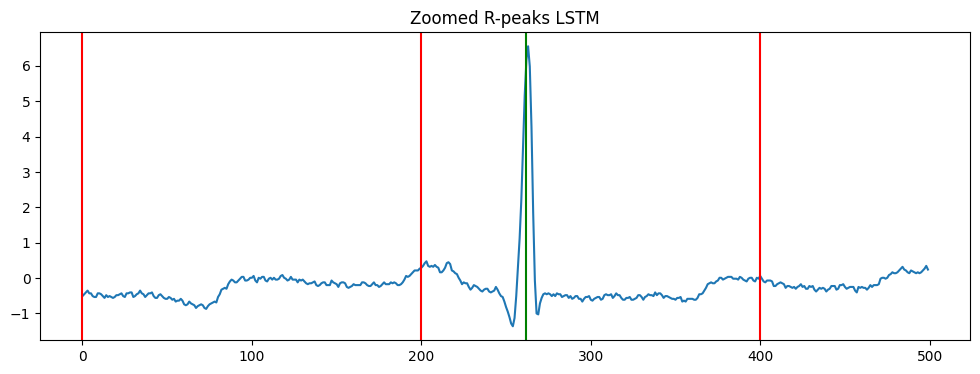

In [23]:
start = 400
end = 900

plt.figure(figsize=(12,4))

plt.plot(signal[start:end])

for p in r_peaks:
    if start <= p <= end:
        plt.axvline(p-start, color='g')

for p in pred_positions:
    if start <= p <= end:
        plt.axvline(p-start, color='r')

plt.title("Zoomed R-peaks LSTM")
plt.show()

## Saving the Model

The trained model is saved so that it can be used later without retraining.

In [38]:
torch.save(model.state_dict(), "lstm_model.pth")
print("Model saved")

Model saved


## Conclusion

In this project, an LSTM-based deep learning model was developed for ECG signal analysis and R-peak detection.

The ECG signal was preprocessed and used to train the LSTM model using labeled peak data.  
During training, the loss was monitored and the model parameters were updated using an optimizer.

The trained model achieved high accuracy on both training and testing datasets, which shows that the model successfully learned the temporal patterns present in the signal.

The predicted peak positions were compared with actual peaks, and the plotted results confirmed that the model detects peaks correctly.

This demonstrates that LSTM networks are effective for time-series signal processing and can be applied to biomedical signal analysis tasks such as ECG peak detection.